In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## **Carga de datos**

In [2]:
file_path = "online_shoppers_intention.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "henrysue/online-shoppers-intention",
  file_path
)

## **Función general de matriz de confusión**

In [3]:
def plot_single_confusion_matrix(model, X_test, y_test, class_names=None, title="Matriz de Confusión"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()
    
def plot_isolation_forest_matrix(y_true, y_pred_final, class_names=None, title="Isolation Forest"):
    cm = confusion_matrix(y_true, y_pred_final)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    
    plt.title(title)
    plt.xlabel('Predicción (Mapeada)')
    plt.ylabel('Realidad')
    plt.show()

## **Preprocesado de los datos**

In [4]:
# Eliminación de duplicados
df_clean = df.drop_duplicates(keep='first')

In [5]:
n = df_clean.shape[0]
d = df_clean.shape[1]

print(f'Conjunto de datos con {n} filas y {d} columnas')

Conjunto de datos con 12205 filas y 18 columnas


In [6]:
meses_map = {'Jan': 1, 'Feb':2, 'Mar':3, 'Apr': 4, 'May':5, 'June':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df_clean['Month'] = df_clean['Month'].map(meses_map)
df_clean = pd.get_dummies(df_clean, columns=['VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'], drop_first=True, dtype=int)

df_clean['Weekend'] = df_clean['Weekend'].astype(int)
df_clean['Revenue'] = df_clean['Revenue'].astype(int)

In [7]:
df_clean.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
n = df_clean.shape[0]
d = df_clean.shape[1]

print(f'Conjunto de datos con {n} filas y {d} columnas')

Conjunto de datos con 12205 filas y 61 columnas


In [9]:
y = df_clean['Revenue']
X = df_clean.drop('Revenue', axis=1)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
print('Distribución para y_train:',Counter(y_train))

Distribución para y_train: Counter({0: 8238, 1: 1526})


In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('Distribución para y_train re-sampleado:', Counter(y_train_smote))

Distribución para y_train re-sampleado: Counter({1: 8238, 0: 8238})


## **Modelos**

### **Regresión logística**

Muy útil como baseline de rendimiento para el resto de modelos

              precision    recall  f1-score   support

           0       0.94      0.89      0.92      2059
           1       0.54      0.71      0.62       382

    accuracy                           0.86      2441
   macro avg       0.74      0.80      0.77      2441
weighted avg       0.88      0.86      0.87      2441



/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/Aplicaciones de la IA/Proyetos/proyecto-1-AIA-Marketing_Digital/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


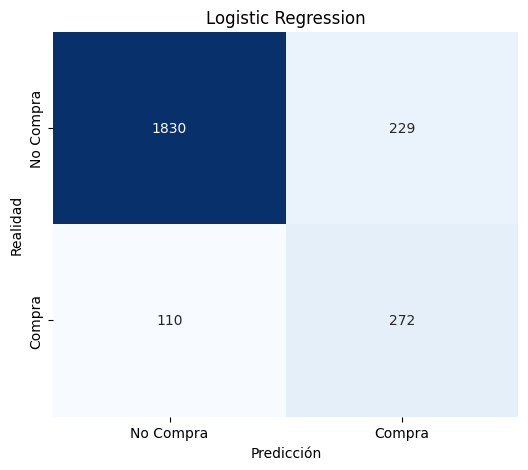

In [13]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)

proba = lr.predict_proba(X_test)[:, 1]
preds = (proba >= 0.5).astype(int)

print(classification_report(y_test, preds))

plot_single_confusion_matrix(lr, X_test, y_test, class_names=['No Compra', 'Compra'], title="Logistic Regression")

> **Nota**: Para los siguientes modelos hacemos uso `GridSearch`, lo cual nos permite comprobar combinaciones de hiperparámetros en rangos definidos por nosotros con el objetivo de maximizar la métrica que se deseé (en este caso F1 de la clase positiva). Esto permite ahorrar mucho tiempo a la hora probar las configuraciones de una en una de manera manual.

### **Isolation Forest**

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Mejores parámetros: {'bootstrap': True, 'contamination': 0.15, 'max_features': 0.5, 'max_samples': 'auto', 'n_estimators': 100}
Mejor F1-Score en entrenamiento: 0.2251850957792257
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      2059
           1       0.26      0.25      0.26       382

    accuracy                           0.77      2441
   macro avg       0.56      0.56      0.56      2441
weighted avg       0.77      0.77      0.77      2441



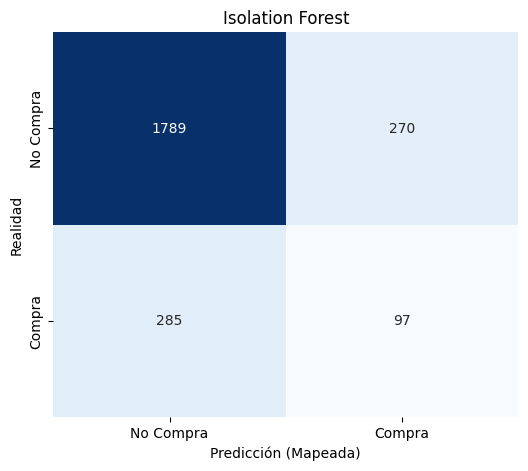

In [14]:
iso_forest = IsolationForest(contamination=0.15, random_state=42)

def isolation_forest_f1_scorer(y_true, y_pred):
    y_pred_mapped = [1 if i == -1 else 0 for i in y_pred]
    return f1_score(y_true, y_pred_mapped)

isolation_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_samples': [0.5, 0.75, 1.0, 'auto'],    
    'contamination': [0.01, 0.05, 0.1, 0.15],
    'max_features': [0.5, 1.0],               
    'bootstrap': [True, False]                  
}

custom_f1 = make_scorer(isolation_forest_f1_scorer)

isolation_grid_search = GridSearchCV(
    estimator=iso_forest, 
    param_grid=isolation_param_grid, 
    cv=5,                 
    scoring=custom_f1,         
    n_jobs=-1,            
    verbose=1,   
)

isolation_grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {isolation_grid_search.best_params_}")
print(f"Mejor F1-Score en entrenamiento: {isolation_grid_search.best_score_}")

best_isof = isolation_grid_search.best_estimator_
y_pred = best_isof.predict(X_test)

y_pred_final = [1 if i == -1 else 0 for i in y_pred]

print(classification_report(y_test, y_pred_final))
plot_isolation_forest_matrix(y_test, y_pred_final, class_names=['No Compra', 'Compra'])

### **RandomForest**

#### Sin SMOTE

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Mejor F1-Score en entrenamiento: 0.6750502301952142
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2059
           1       0.65      0.73      0.68       382

    accuracy                           0.90      2441
   macro avg       0.80      0.83      0.81      2441
weighted avg       0.90      0.90      0.90      2441



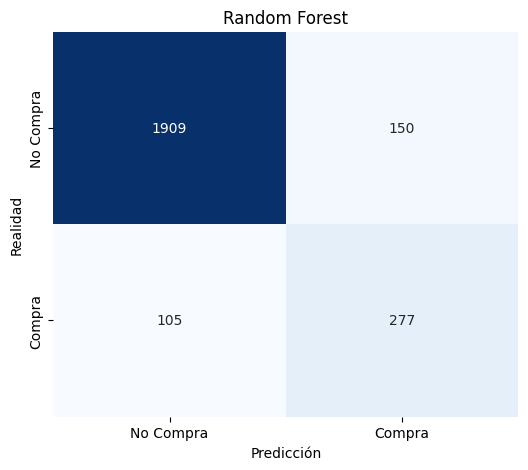

In [15]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_param_grid = {
    'n_estimators': [100, 200, 300],       
    'max_depth': [None, 10, 20],           
    'min_samples_split': [2, 5, 10],       
    'max_features': ['sqrt', 'log2'],      
}


rf_grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=rf_param_grid, 
    cv=5,                 
    scoring='f1',         
    n_jobs=-1,            
    verbose=1,
    
)

rf_grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {rf_grid_search.best_params_}")
print(f"Mejor F1-Score en entrenamiento: {rf_grid_search.best_score_}")

best_rf = rf_grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))
plot_single_confusion_matrix(best_rf, X_test, y_test, class_names=['No Compra', 'Compra'], title="Random Forest")

#### Sin SMOTE

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1-Score en entrenamiento: 0.9010861065656612
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.62      0.71      0.66       382

    accuracy                           0.89      2441
   macro avg       0.78      0.81      0.80      2441
weighted avg       0.89      0.89      0.89      2441



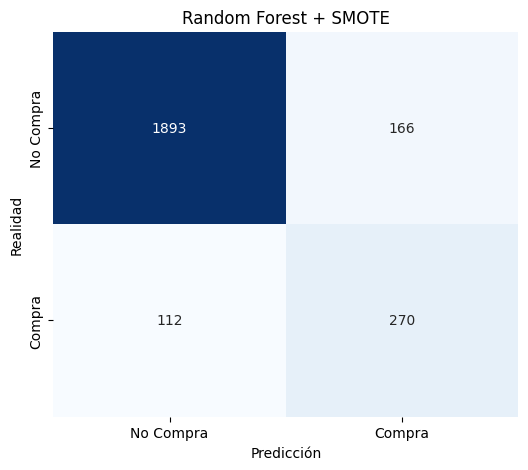

In [16]:
rf_grid_search_smote = GridSearchCV(
    estimator=rf, 
    param_grid=rf_param_grid, 
    cv=5,                 
    scoring='f1',         
    n_jobs=-1,           
    verbose=1
)

rf_grid_search_smote.fit(X_train_smote, y_train_smote)

print(f"Mejores parámetros: {rf_grid_search_smote.best_params_}")
print(f"Mejor F1-Score en entrenamiento: {rf_grid_search_smote.best_score_}")

best_rf = rf_grid_search_smote.best_estimator_
y_pred2 = best_rf.predict(X_test)

print(classification_report(y_test, y_pred2))
plot_single_confusion_matrix(best_rf, X_test, y_test, class_names=['No Compra', 'Compra'], title="Random Forest + SMOTE")

### **XGBoost**

#### Sin SMOTE

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros XGB: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Mejor F1-Score en entrenamiento: 0.6582384852279966
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.72      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



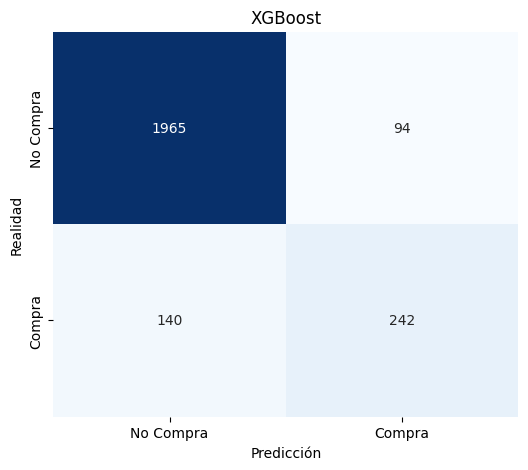

In [17]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_param_grid = {
    'n_estimators': [200, 300],           
    'max_depth': [3, 6, 9],               
    'learning_rate': [0.01, 0.1, 0.2],    
    'subsample': [0.8, 1.0],              
    'colsample_bytree': [0.8, 1.0]        
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,                 
    scoring='f1',        
    n_jobs=-1,
    verbose=1,
)

xgb_grid_search.fit(X_train, y_train)

print(f"Mejores parámetros XGB: {xgb_grid_search.best_params_}")
print(f"Mejor F1-Score en entrenamiento: {xgb_grid_search.best_score_}")

best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)


print(classification_report(y_test, y_pred_xgb))
plot_single_confusion_matrix(best_xgb, X_test, y_test, class_names=['No Compra', 'Compra'], title="XGBoost")

### Con SMOTE

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Mejor F1-Score en entrenamiento: 0.8996626091805131
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2059
           1       0.60      0.74      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.82      0.79      2441
weighted avg       0.89      0.88      0.89      2441



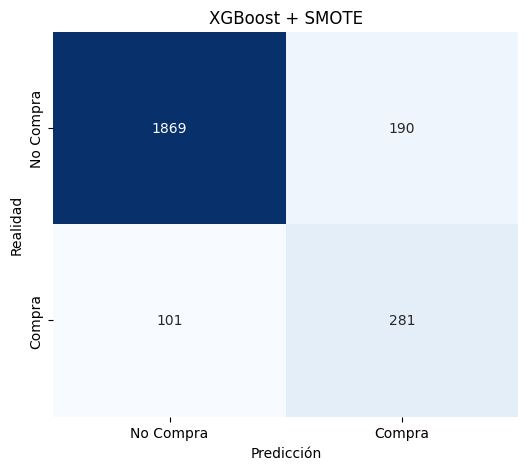

In [18]:
xgb_grid_search_smote = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,                 
    scoring='f1',        
    n_jobs=-1,
    verbose=1
)

xgb_grid_search_smote.fit(X_train_smote, y_train_smote)

print(f"Mejores parámetros XGB: {xgb_grid_search_smote.best_params_}")
print(f"Mejor F1-Score en entrenamiento: {xgb_grid_search_smote.best_score_}")

best_xgb = xgb_grid_search_smote.best_estimator_
y_pred_xgb2 = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb2))
plot_single_confusion_matrix(best_xgb, X_test, y_test, class_names=['No Compra', 'Compra'], title="XGBoost + SMOTE")

"Aunque un F1-Score de 0.68 pueda parecer alejado de la perfección, en el contexto de la navegación web representa un salto competitivo inmenso. El modelo permite pasar de una estrategia masiva e ineficiente a una micro-segmentada, donde 2 de cada 3 impactos publicitarios se realizan sobre usuarios con una intención real de compra, optimizando el retorno de inversión (ROI) y reduciendo el desperdicio de presupuesto en un 400% respecto a una campaña sin segmentación."